Import Libraries

In [2]:
import numpy as np

In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, classification_report, roc_curve

In [9]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
import shap

In [11]:
import warnings

In [12]:
warnings.filterwarnings('ignore')

Load Dataset

In [13]:
df = pd.read_csv(r"C:\Users\gauri\Downloads\application_train.csv.zip")

In [14]:
df = df.sample(10000, random_state=42)

In [15]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
245895,384575,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0
98194,214010,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
36463,142232,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
249923,389171,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
158389,283617,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0


**Understand Data**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 245895 to 211344
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 9.4+ MB


In [17]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,9999.000000,9.988000e+03,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,8704.000000,8704.000000,8704.000000,8704.000000,8704.000000,8704.000000
mean,278016.967200,0.082300,0.425200,1.805540e+05,6.013828e+05,27130.175068,5.402393e+05,0.021165,-16048.004500,62648.627000,...,0.008600,0.000800,0.000400,0.000600,0.007468,0.006893,0.034352,0.268842,0.255285,1.870519
std,101990.606345,0.274835,0.725987,1.172164e+06,4.059959e+05,14525.332048,3.719097e+05,0.014136,4383.075623,140304.398412,...,0.092341,0.028274,0.019997,0.024489,0.096184,0.105891,0.193164,0.924777,0.600735,1.862968
min,100020.000000,0.000000,0.000000,2.700000e+04,4.500000e+04,2542.500000,4.500000e+04,0.000533,-25197.000000,-16607.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190851.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16546.500000,2.385000e+05,0.010032,-19709.000000,-2771.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278169.000000,0.000000,0.000000,1.485000e+05,5.127210e+05,25024.500000,4.500000e+05,0.018850,-15757.000000,-1188.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,365627.250000,0.000000,1.000000,2.025000e+05,8.100000e+05,34591.500000,6.795000e+05,0.028663,-12344.750000,-292.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456238.000000,1.000000,5.000000,1.170000e+08,3.600000e+06,230161.500000,3.600000e+06,0.072508,-7694.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,5.000000,5.000000,17.000000,5.000000,18.000000


In [18]:
df.shape

(10000, 122)

**Target Variable**

In [19]:
df['TARGET'].value_counts()

TARGET
0    9177
1     823
Name: count, dtype: int64

**Handle MIssing Values**

In [20]:
# Drop columns with too many missing values

In [21]:
missing = df.isnull().sum()

In [22]:
missing

SK_ID_CURR                       0
TARGET                           0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
                              ... 
AMT_REQ_CREDIT_BUREAU_DAY     1296
AMT_REQ_CREDIT_BUREAU_WEEK    1296
AMT_REQ_CREDIT_BUREAU_MON     1296
AMT_REQ_CREDIT_BUREAU_QRT     1296
AMT_REQ_CREDIT_BUREAU_YEAR    1296
Length: 122, dtype: int64

In [23]:
cols_to_drop = missing[missing > 0.4].index

In [24]:
df = df.drop(columns = cols_to_drop)

In [25]:
# Fill remaining missing values

In [26]:
df = df.fillna(df.median(numeric_only = True))

Encode Categorical Variables

In [27]:
df = pd.get_dummies(df, drop_first = True)

Feature Engineering

In [28]:
df['credit_income_ratio'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

In [29]:
df

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA,credit_income_ratio
245895,384575,0,2,207000.0,465457.5,0.009630,-13297,-762,-637.0,-4307,...,False,False,False,False,False,False,False,False,False,2.248587
98194,214010,0,0,247500.0,1281712.5,0.006852,-14778,-1141,-1610.0,-4546,...,False,False,False,False,False,False,False,False,False,5.178636
36463,142232,0,0,202500.0,495000.0,0.035792,-17907,-639,-2507.0,-1461,...,False,False,False,False,False,False,False,False,False,2.444444
249923,389171,0,0,247500.0,254700.0,0.046220,-19626,-6982,-11167.0,-3158,...,False,False,False,False,False,False,False,False,False,1.029091
158389,283617,0,0,112500.0,308133.0,0.018850,-20327,-1105,-7299.0,-494,...,False,False,False,False,False,False,False,False,False,2.738960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94862,210148,0,2,247500.0,270000.0,0.007330,-11761,-770,-189.0,-4041,...,False,False,False,False,False,False,False,False,False,1.090909
246937,385756,0,2,225000.0,1762110.0,0.006629,-9595,-288,-4089.0,-2224,...,False,False,False,False,False,False,False,False,False,7.831600
307204,455912,0,0,108000.0,291384.0,0.030755,-23278,-7289,-124.0,-4560,...,False,False,False,False,False,False,False,False,False,2.698000
110720,228443,0,0,306000.0,582804.0,0.006629,-22732,365243,-4749.0,-4749,...,False,False,False,False,False,False,False,False,True,1.904588


Split Data

In [30]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train MOdel

In [39]:
rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


Predictions

In [41]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

Accuracy

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9255


Confusion Matrix

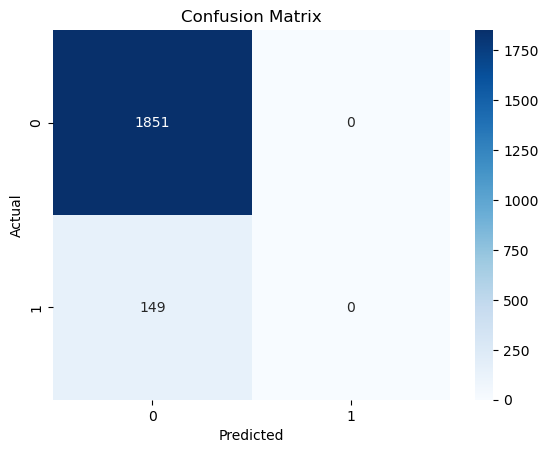

In [43]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1851
           1       0.00      0.00      0.00       149

    accuracy                           0.93      2000
   macro avg       0.46      0.50      0.48      2000
weighted avg       0.86      0.93      0.89      2000



ROC AUC Score

In [45]:
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.6506223735401506


ROC CURVE

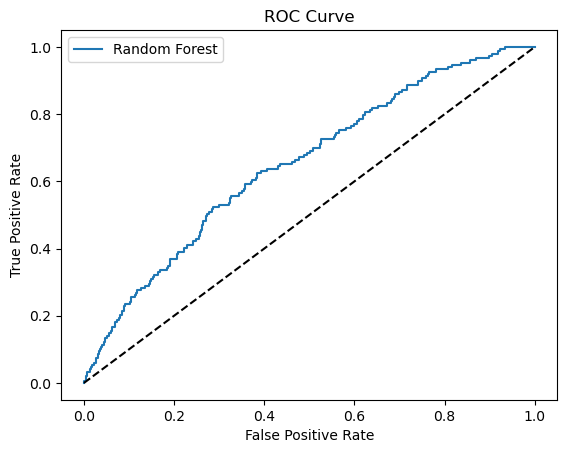

In [46]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [49]:
X_shap = X_test.sample(20, random_state=42)

In [50]:
explainer = shap.TreeExplainer(rf)

In [51]:
shap_values = explainer.shap_values(
    X_shap,
    check_additivity=False
)

In [53]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(20, 131, 2)


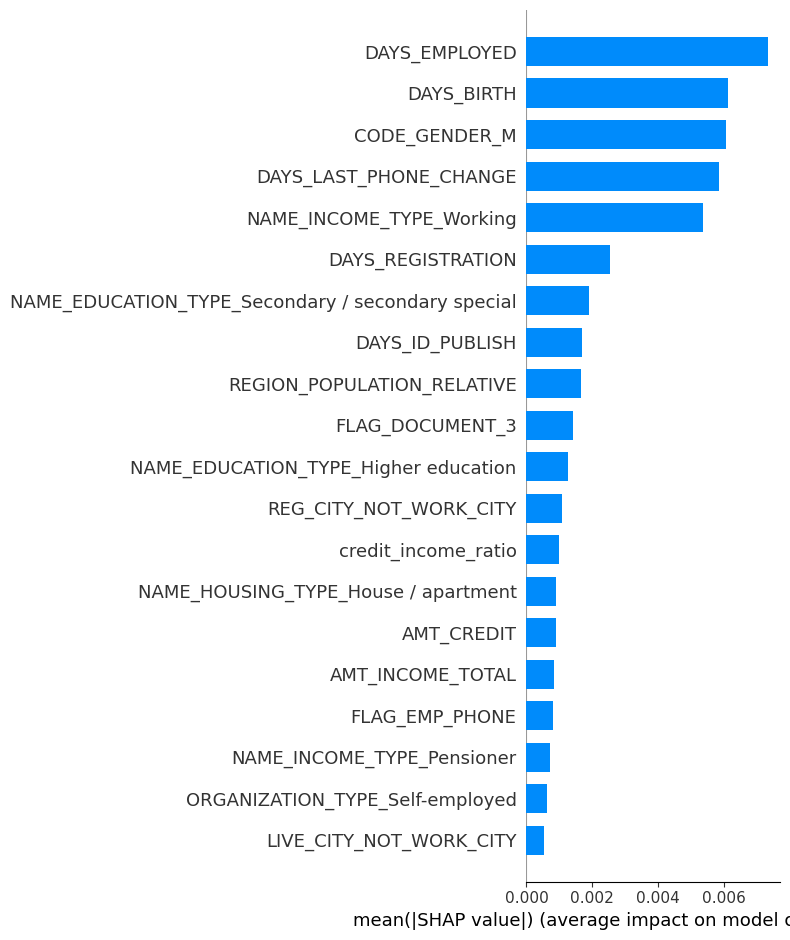

In [54]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_shap,
    plot_type="bar"
)

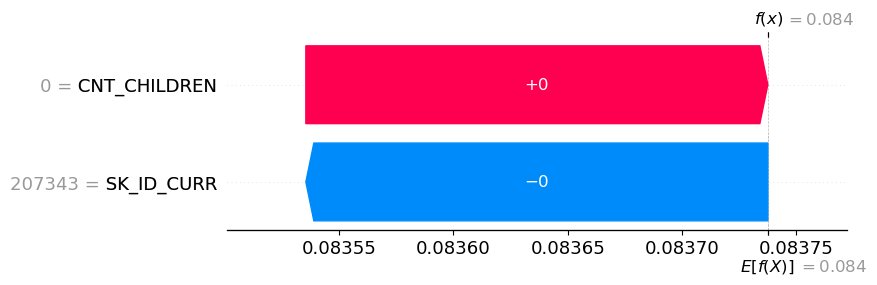

In [58]:
import shap

# Create Explanation object manually
waterfall_exp = shap.Explanation(
    values=shap_values[1][0],
    base_values=explainer.expected_value[1],
    data=X_shap.iloc[0],
    feature_names=X_shap.columns
)

# Waterfall plot
shap.plots.waterfall(waterfall_exp)